# MSFT Forecasting: ARIMA, VECM and GARCH

DA4421 Time Series Econometrics take-home assignment. Daily MSFT closing prices (April 2015 to April 2026) with S&P 500 and VIX as extra variables.

## PART 1: Univariate ARIMA(p,d,q) on Daily Data

### Load, Clean, and Explore Data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Download data
tickers = ['MSFT', '^GSPC', '^VIX']
data = yf.download(tickers, start='2015-04-01', end='2026-05-01', progress=False)['Close']
data.columns = ['MSFT', 'SP500', 'VIX']

# Use daily data
df = data.copy()

print(df.head())
print(df.info())
print(df.describe())
print(f"From {df.index.min()} to {df.index.max()}")
print(f"Missing values: {df.isna().sum()}")

# Save
df.to_csv('MSFT_Multivariate_Data.csv')


                 MSFT        SP500    VIX
Date                                     
2015-04-01  34.736565  2059.689941  15.11
2015-04-02  34.369770  2066.959961  14.67
2015-04-06  35.444607  2080.620117  14.74
2015-04-07  35.427551  2076.330078  14.78
2015-04-08  35.333706  2081.899902  13.98
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2787 entries, 2015-04-01 to 2026-04-30
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MSFT    2787 non-null   float64
 1   SP500   2787 non-null   float64
 2   VIX     2787 non-null   float64
dtypes: float64(3)
memory usage: 87.1 KB
None
              MSFT        SP500          VIX
count  2787.000000  2787.000000  2787.000000
mean    214.649375  3743.954398    18.428281
std     143.901486  1410.020410     7.130172
min      34.369770  1829.079956     9.140000
25%      79.493378  2588.050049    13.595000
50%     202.800964  3443.439941    16.660000
75%     322.918488  4529.600098    2

### Visualization of Time Series Data

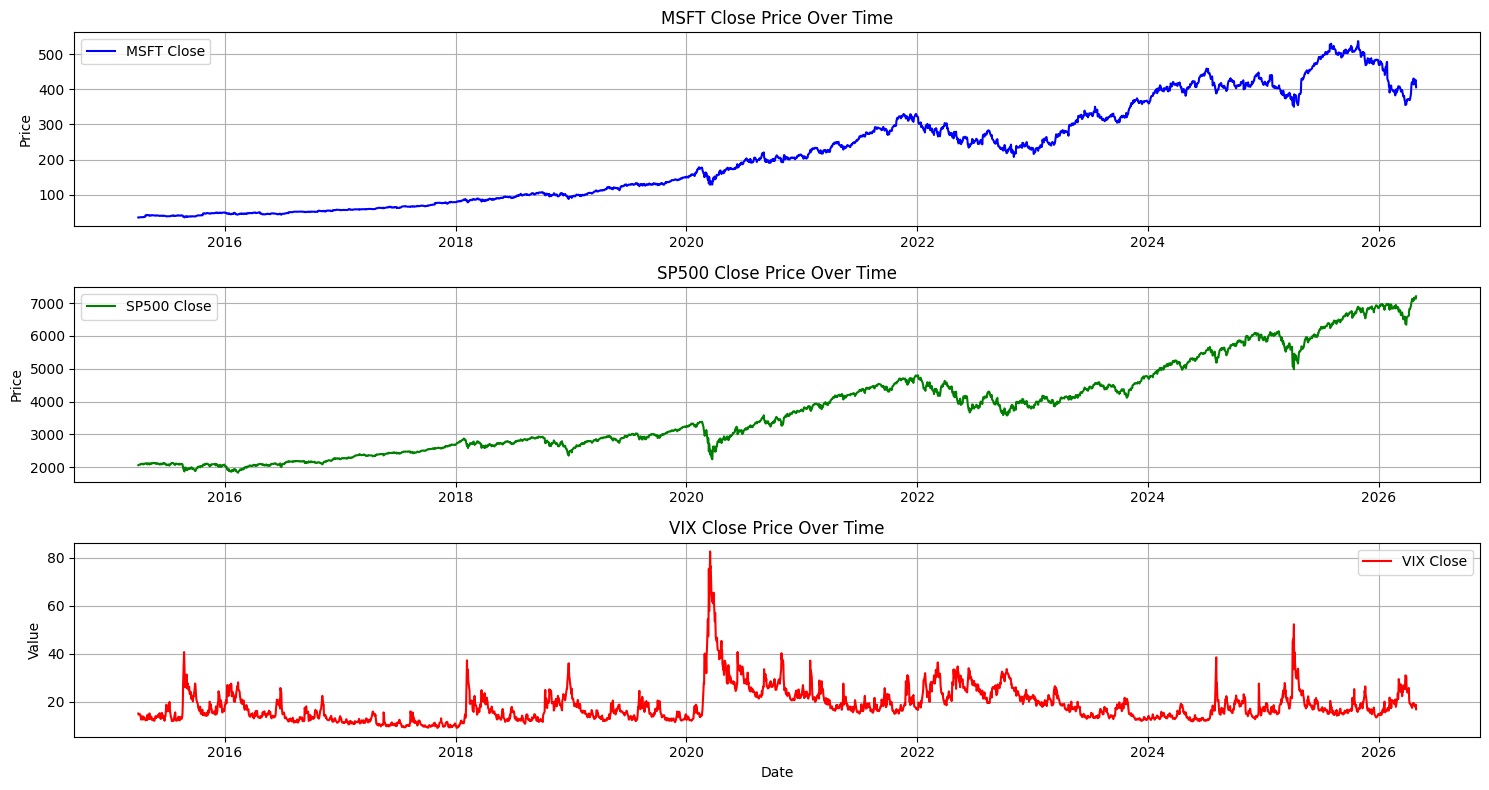

In [2]:
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1) # 3 rows, 1 column, 1st plot
plt.plot(df.index, df['MSFT'], label='MSFT Close', color='blue')
plt.title('MSFT Close Price Over Time')
plt.ylabel('Price')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2) # 3 rows, 1 column, 2nd plot
plt.plot(df.index, df['SP500'], label='SP500 Close', color='green')
plt.title('SP500 Close Price Over Time')
plt.ylabel('Price')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3) # 3 rows, 1 column, 3rd plot
plt.plot(df.index, df['VIX'], label='VIX Close', color='red')
plt.title('VIX Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

####
We use Microsoft (MSFT) daily closing prices from April 2015 to April 2026 (2,787 observations).

The series displays a strong upward trend, especially after 2020, and shows a sharp drop during the COVID‑19 crash in March 2020, visible in the structural‑break plot.

VIX and S&P 500 are also downloaded for later use in a multivariate model.

### Test for Stationarity & Decide Differencing (d)

In [3]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(series, title=""):
    print(f"\n=== {title} ===")
    adf = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {adf[0]:.6f}, p-value: {adf[1]:.6f}')
    kpss_stat, kpss_p, _, _ = kpss(series, regression='c')
    print(f'KPSS Statistic: {kpss_stat:.6f}, p-value: {kpss_p:.6f}')


stationarity_tests(df['MSFT'], "Original MSFT Series")
stationarity_tests(df['MSFT'].diff().dropna(), "First Difference of MSFT Series")




=== Original MSFT Series ===
ADF Statistic: -0.609983, p-value: 0.868710
KPSS Statistic: 8.368368, p-value: 0.010000

=== First Difference of MSFT Series ===


/tmp/ipykernel_576/143962386.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, _, _ = kpss(series, regression='c')


ADF Statistic: -17.524786, p-value: 0.000000
KPSS Statistic: 0.053690, p-value: 0.100000


/tmp/ipykernel_576/143962386.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_p, _, _ = kpss(series, regression='c')


####
ADF test on levels: p‑value = 0.87 → fail to reject unit root.

KPSS test: rejects stationarity.

After first differencing, the ADF p‑value is ~0 and the KPSS p‑value is 0.10, indicating the differenced series is stationary.

Conclusion: MSFT daily prices are I(1) → we set d=1.

### Check Seasonality & Structural Breaks

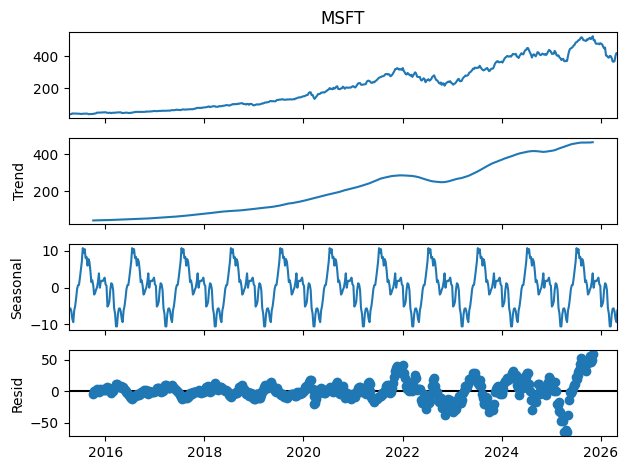

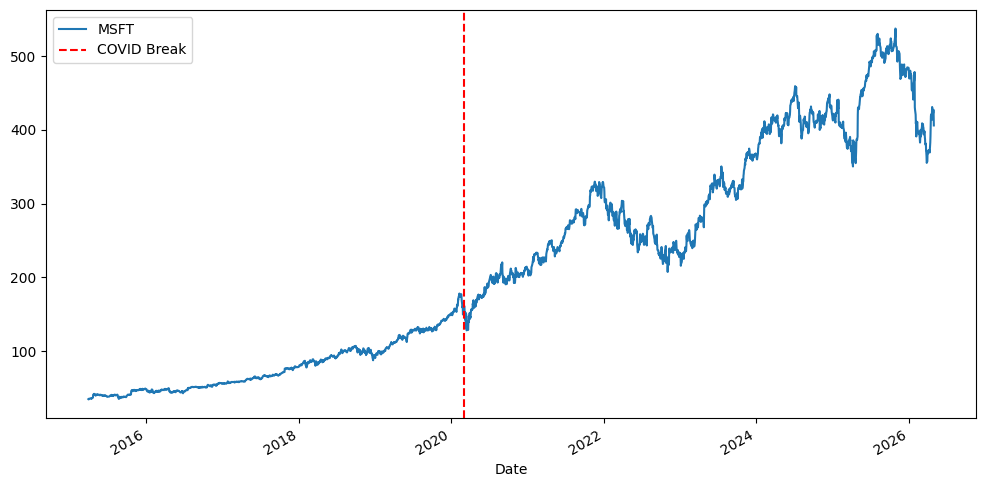

In [4]:
# Seasonal decomposition (additive/multiplicative)
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df['MSFT'].resample('W').mean(), model='additive', period=52)  # weekly
decomp.plot()
plt.show()

# Structural breaks (simple Chow or visual)
plt.figure(figsize=(12,6))
df['MSFT'].plot()
plt.axvline('2020-03-01', color='red', linestyle='--', label='COVID Break')
plt.legend()
plt.show()

### ACF/PACF for p,q + Auto ARIMA

#### Plot ACF and PACF of first differenced series

In [5]:
import sys
!{sys.executable} -m pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 9.1 MB/s eta 0:00:00


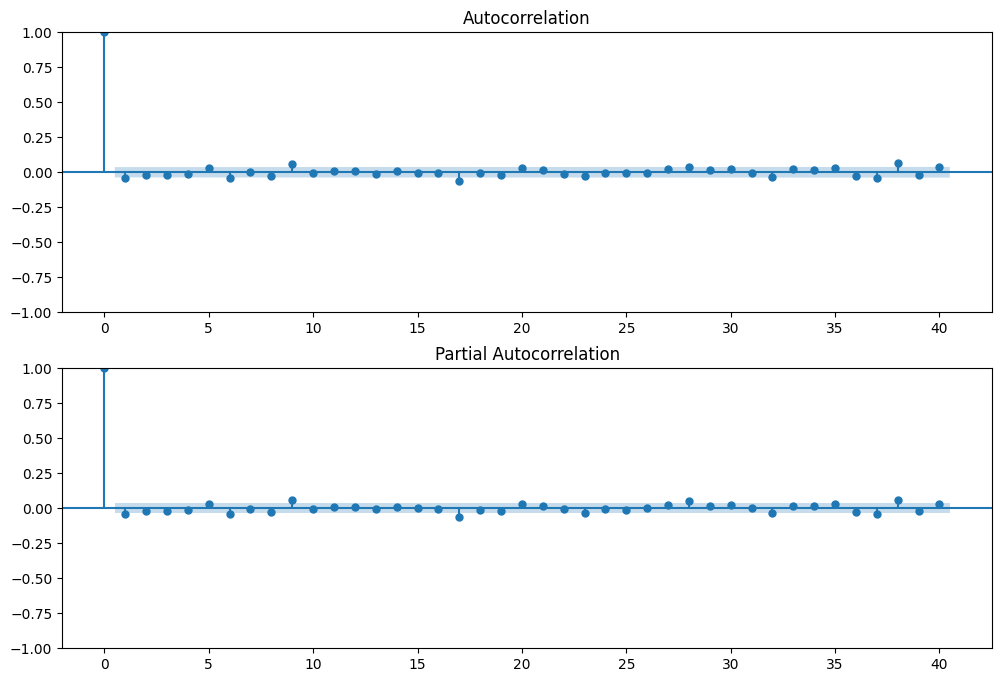

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

# Plot ACF and PACF of first differenced series
fig, axes = plt.subplots(2,1, figsize=(12,8))
plot_acf(df['MSFT'].diff().dropna(), lags=40, ax=axes[0])
plot_pacf(df['MSFT'].diff().dropna(), lags=40, ax=axes[1])
plt.show()



#### ACF/PACF with weekly lag markers

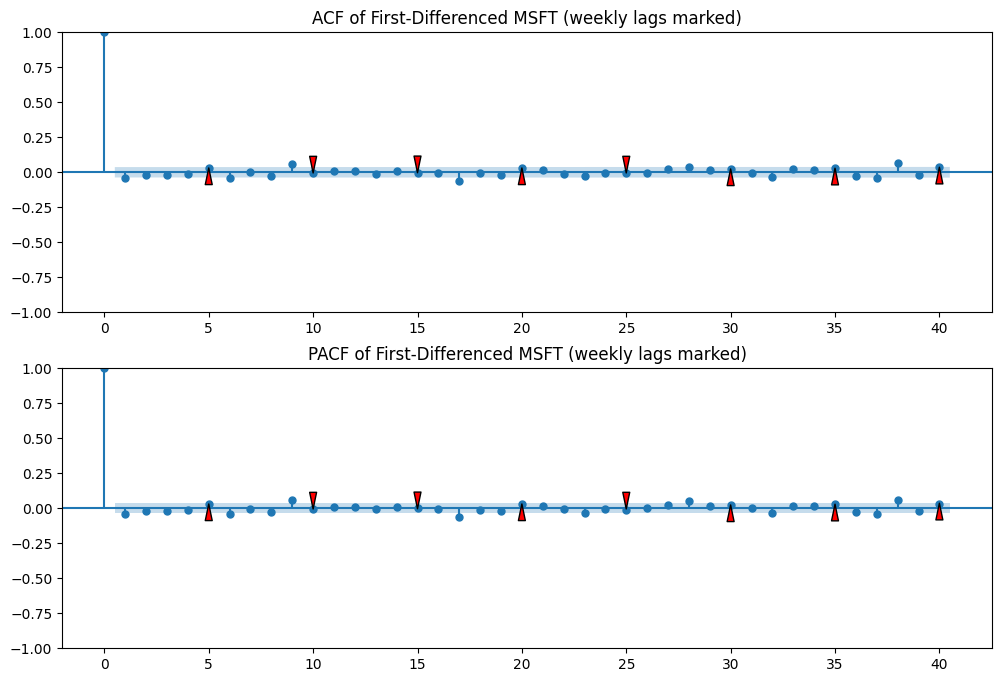

In [7]:
fig, axes = plt.subplots(2,1, figsize=(12,8))
diff = df['MSFT'].diff().dropna()

plot_acf(diff, lags=40, ax=axes[0])
axes[0].set_title("ACF of First‑Differenced MSFT (weekly lags marked)")
for lag in [5,10,15,20,25,30,35,40]:
    axes[0].annotate('', xy=(lag, diff.autocorr(lag)), xytext=(lag, 0.02),
                arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5))

plot_pacf(diff, lags=40, ax=axes[1])
axes[1].set_title("PACF of First‑Differenced MSFT (weekly lags marked)")
for lag in [5,10,15,20,25,30,35,40]:
    axes[1].annotate('', xy=(lag, diff.autocorr(lag)), xytext=(lag, 0.02),
                arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5))
plt.show()

#### Auto ARIMA

In [8]:
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

# Auto ARIMA
model = pm.auto_arima(df['MSFT'],
                      start_p=0, start_q=0,
                      max_p=5, max_q=5,
                      d=1,          # We already know d=1
                      seasonal=True, m=5,   # or try m=21 (trading days)
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True)

print(model.summary())

# Compare SARIMA vs. ARIMA (non‑seasonal)
ts = df['MSFT'] # Define ts for the ARIMA model
non_seasonal = ARIMA(ts, order=(1,1,1)).fit()

print("=== Model Comparison ===")
print(f"Non‑seasonal ARIMA(1,1,1) AIC: {non_seasonal.aic:.2f}, BIC: {non_seasonal.bic:.2f}")
print(f"Seasonal SARIMA(1,1,1)(0,0,1)_5 AIC: {model.aic():.2f}, BIC: {model.bic():.2f}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=15807.285, Time=6.08 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=15806.157, Time=0.27 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=15802.380, Time=2.24 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=15802.180, Time=3.18 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=15807.065, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[5] intercept   : AIC=15802.586, Time=0.65 sec
 ARIMA(0,1,1)(1,0,1)[5] intercept   : AIC=15804.165, Time=10.67 sec
 ARIMA(0,1,1)(0,0,2)[5] intercept   : AIC=15804.158, Time=4.83 sec
 ARIMA(0,1,1)(1,0,0)[5] intercept   : AIC=15802.197, Time=2.00 sec
 ARIMA(0,1,1)(1,0,2)[5] intercept   : AIC=15806.153, Time=7.06 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=15805.339, Time=1.08 sec
 ARIMA(1,1,1)(0,0,1)[5] intercept   : AIC=15801.169, Time=2.48 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=15802.890, Time=1.04 sec
 ARIMA(1,1,1)(1,0,1)[5] intercept   : AIC=15803.163, Time=3.00 sec
 ARIMA(1,1,1)(0,0,

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


=== Model Comparison ===
Non‑seasonal ARIMA(1,1,1) AIC: 15804.42, BIC: 15822.21
Seasonal SARIMA(1,1,1)(0,0,1)_5 AIC: 15801.17, BIC: 15830.83


####
Model Identification: The auto_arima function has successfully identified an ARIMA(1,1,1) model with a seasonal component (0,0,1,5) which minimizes the AIC

Residual Autocorrelation: The Ljung-Box test shows a high p-value (0.79). There's no significant autocorrelation left in model's residuals, indicating that the model has captured the time-dependent patterns effectively.

### Fit, Diagnose, Forecast

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                    
Dep. Variable:                            MSFT   No. Observations:                 2787
Model:             ARIMA(1, 1, 1)x(0, 0, 1, 5)   Log Likelihood               -7897.367
Date:                         Thu, 08 Oct 2026   AIC                          15802.733
Time:                                 08:44:13   BIC                          15826.463
Sample:                                      0   HQIC                         15811.301
                                        - 2787                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6830      0.140      4.895      0.000       0.410       0.957
ma.L1         -0.7210      0.133     -5.427      0.000     

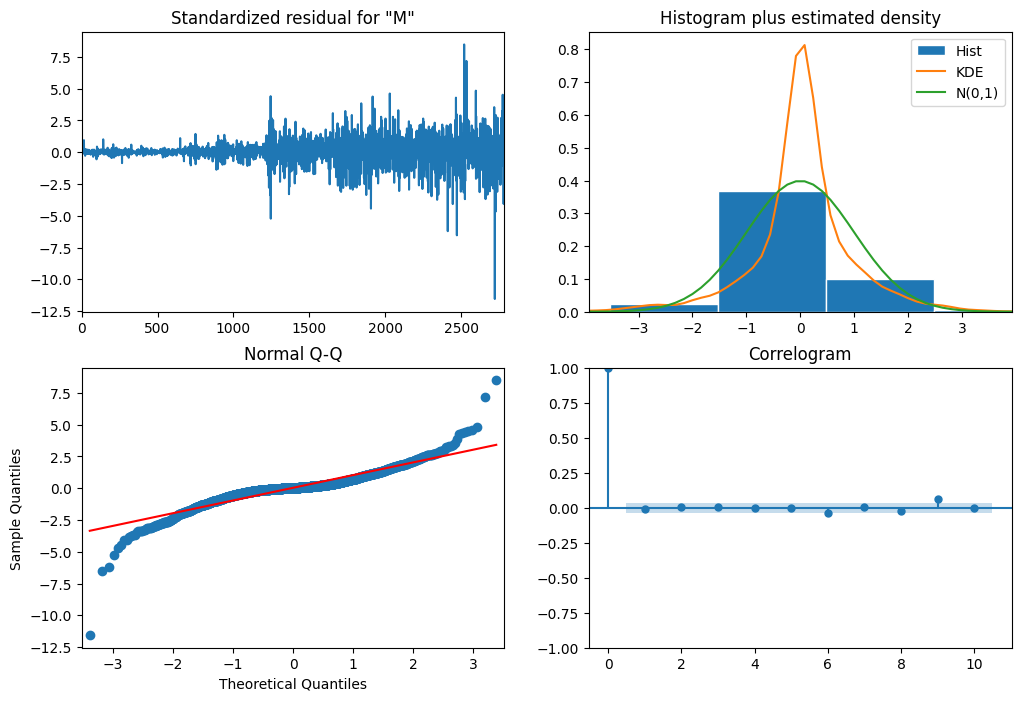

Ljung‑Box test results (p‑values):
      lb_stat  lb_pvalue
10  15.134219   0.127245
20  30.192077   0.066801
30  43.178251   0.056508


In [9]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf

# Extract order and seasonal_order from the auto_arima model
p, d, q = model.order
P, D, Q, s = model.seasonal_order

# Define the time series
ts = df['MSFT']

arima_model = ARIMA(ts, order=(p,d,q), seasonal_order=(P,D,Q,s)).fit()
print(arima_model.summary())

# Diagnostics
arima_model.plot_diagnostics(figsize=(12,8))
plt.show()

# Residual tests using correct Ljung‑Box
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(arima_model.resid, lags=[10,20,30], return_df=True)
print("Ljung‑Box test results (p‑values):")
print(lb_test)

#### Forecast

            Forecast  Lower_CI  Upper_CI
2026-05-01    407.08    399.01    415.15
2026-05-04    407.50    396.30    418.71
2026-05-05    407.95    394.43    421.46
2026-05-06    407.93    392.52    423.35
2026-05-07    407.42    390.36    424.48
2026-05-08    407.53    388.86    426.20
2026-05-11    407.61    387.48    427.74
2026-05-12    407.66    386.19    429.13
2026-05-13    407.70    384.97    430.43
2026-05-14    407.72    383.81    431.64
2026-05-15    407.74    382.70    432.78
2026-05-18    407.75    381.64    433.86
2026-05-19    407.76    380.61    434.90
2026-05-20    407.76    379.63    435.90
2026-05-21    407.77    378.67    436.86
2026-05-22    407.77    377.75    437.79
2026-05-25    407.77    376.86    438.69
2026-05-26    407.77    375.98    439.56
2026-05-27    407.77    375.14    440.41
2026-05-28    407.77    374.31    441.24
2026-05-29    407.77    373.50    442.05
2026-06-01    407.77    372.71    442.83
2026-06-02    407.77    371.94    443.61
2026-06-03    40

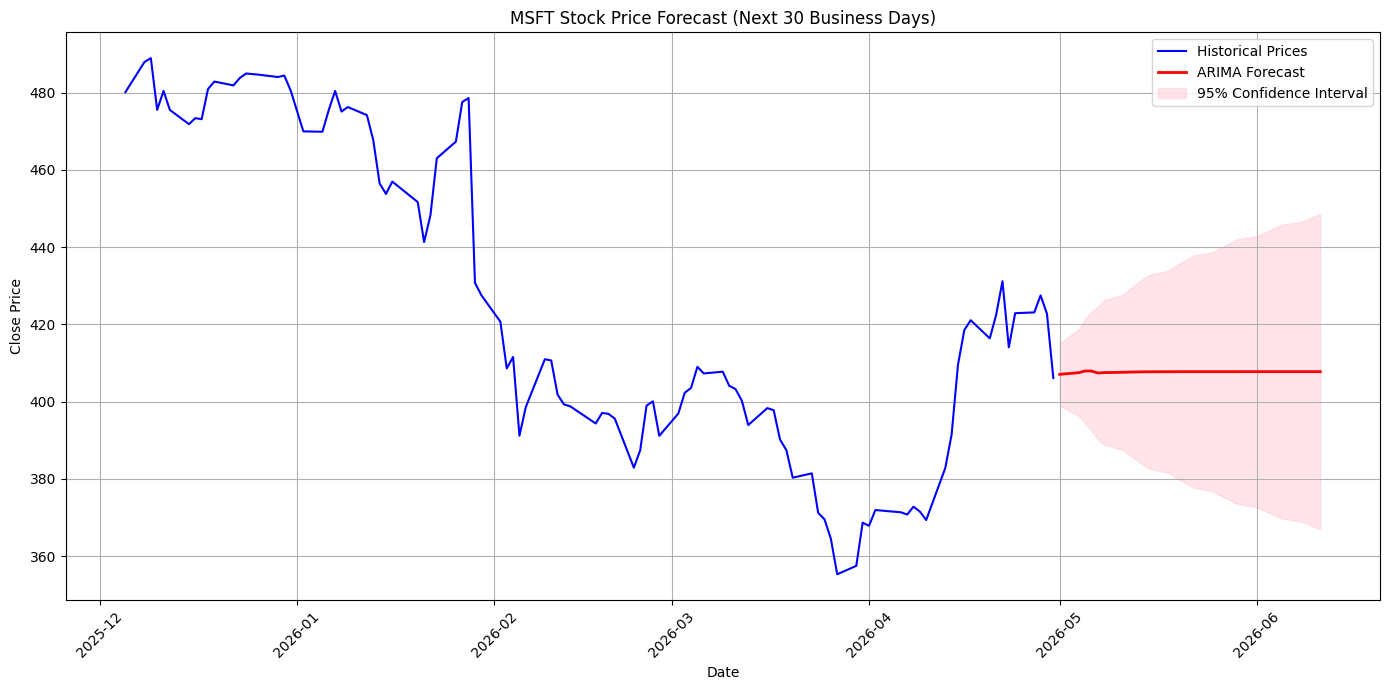

In [10]:
forecast_steps = 30

# Future business days. Passing this index to get_forecast avoids the
# "No supported index is available" error in newer statsmodels versions.
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1),
                             periods=forecast_steps, freq='B')

forecast = arima_model.get_forecast(steps=forecast_steps, index=future_dates)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)

forecast_df = pd.DataFrame({
    'Forecast': forecast_mean.values,
    'Lower_CI': conf_int.iloc[:,0].values,
    'Upper_CI': conf_int.iloc[:,1].values
}, index=future_dates)

print(forecast_df.round(2))

# Plot
plt.figure(figsize=(14, 7))
plt.plot(df['MSFT'][-100:], label='Historical Prices', color='blue')
plt.plot(forecast_df['Forecast'], label='ARIMA Forecast', color='red', linewidth=2)
plt.fill_between(forecast_df.index, forecast_df['Lower_CI'], forecast_df['Upper_CI'],
                 color='pink', alpha=0.4, label='95% Confidence Interval')
plt.title('MSFT Stock Price Forecast (Next 30 Business Days)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Out‑of‑Sample Validation

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


Test MAE : 22.51
Test RMSE: 24.47


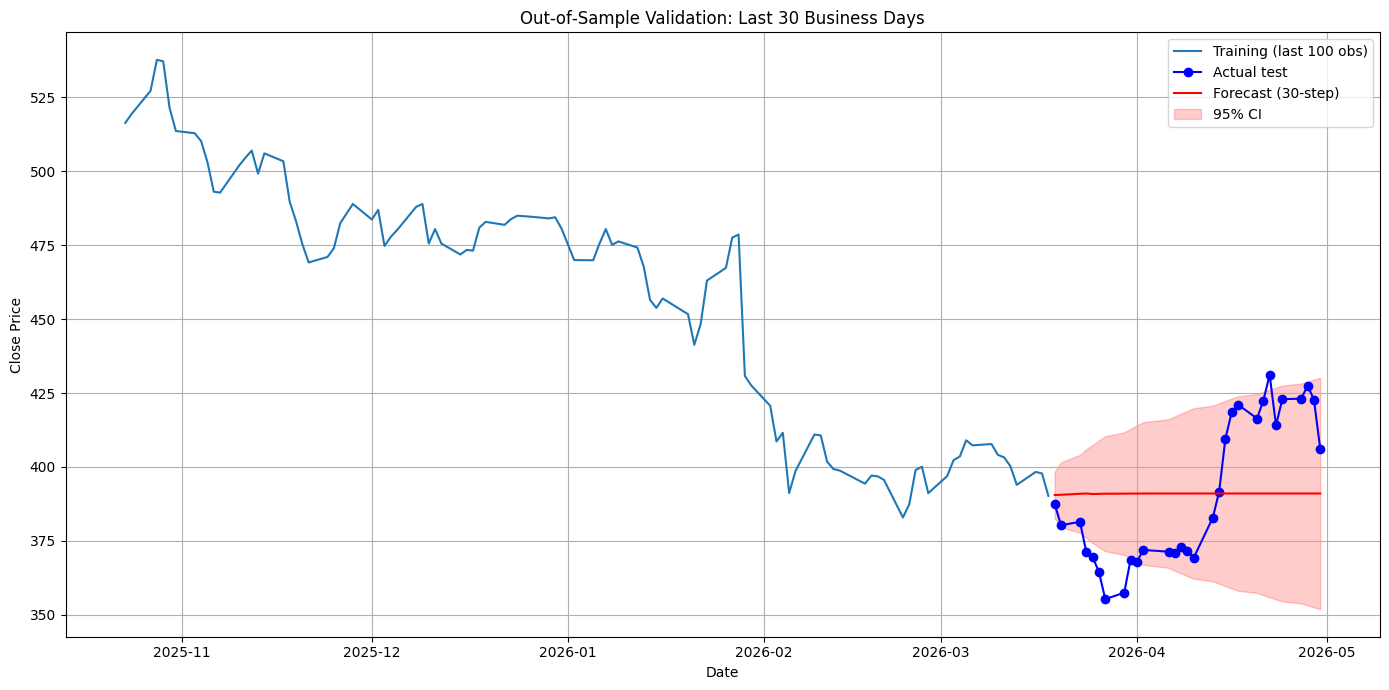

In [11]:
# --- Out‑of‑sample validation (last 30 business days) ---
test_len = 30
train_ts = ts.iloc[:-test_len]   # all except last 30 obs
test_ts  = ts.iloc[-test_len:]   # last 30 obs

# Fit the same SARIMA specification on training data only
model_train = ARIMA(train_ts, order=(p,d,q), seasonal_order=(P,D,Q,s)).fit()

# 30-step-ahead forecast from the end of the training sample
forecast_test = model_train.get_forecast(steps=test_len, index=test_ts.index)
fc_mean = forecast_test.predicted_mean
fc_conf = forecast_test.conf_int(alpha=0.05)

# Align forecast index to test dates
fc_series = pd.Series(fc_mean.values, index=test_ts.index)

# Calculate error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae  = mean_absolute_error(test_ts, fc_series)
rmse = np.sqrt(mean_squared_error(test_ts, fc_series))
print(f'Test MAE : {mae:.2f}')
print(f'Test RMSE: {rmse:.2f}')

# Plot actual vs. forecast
plt.figure(figsize=(14,7))
plt.plot(train_ts.index[-100:], train_ts[-100:], label='Training (last 100 obs)')
plt.plot(test_ts.index, test_ts, label='Actual test', color='blue', marker='o')
plt.plot(fc_series.index, fc_series, label='Forecast (30-step)', color='red')
plt.fill_between(test_ts.index, fc_conf.iloc[:,0], fc_conf.iloc[:,1],
                 alpha=0.2, color='red', label='95% CI')
plt.title('Out‑of‑Sample Validation: Last 30 Business Days')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## PART 2: Multivariate Model (VAR or VECM)

### Prepare the Multivariate Data

In [12]:
# Create a DataFrame for multivariate analysis
mv_df = df[['MSFT', 'SP500', 'VIX']].copy()
mv_df.columns = ['MSFT', 'SP500', 'VIX']

print(mv_df.head())
print(mv_df.info())
print(mv_df.describe())

                 MSFT        SP500    VIX
Date                                     
2015-04-01  34.736565  2059.689941  15.11
2015-04-02  34.369770  2066.959961  14.67
2015-04-06  35.444607  2080.620117  14.74
2015-04-07  35.427551  2076.330078  14.78
2015-04-08  35.333706  2081.899902  13.98
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2787 entries, 2015-04-01 to 2026-04-30
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MSFT    2787 non-null   float64
 1   SP500   2787 non-null   float64
 2   VIX     2787 non-null   float64
dtypes: float64(3)
memory usage: 87.1 KB
None
              MSFT        SP500          VIX
count  2787.000000  2787.000000  2787.000000
mean    214.649375  3743.954398    18.428281
std     143.901486  1410.020410     7.130172
min      34.369770  1829.079956     9.140000
25%      79.493378  2588.050049    13.595000
50%     202.800964  3443.439941    16.660000
75%     322.918488  4529.600098    2

####  Visualise the Series and Their Relationships

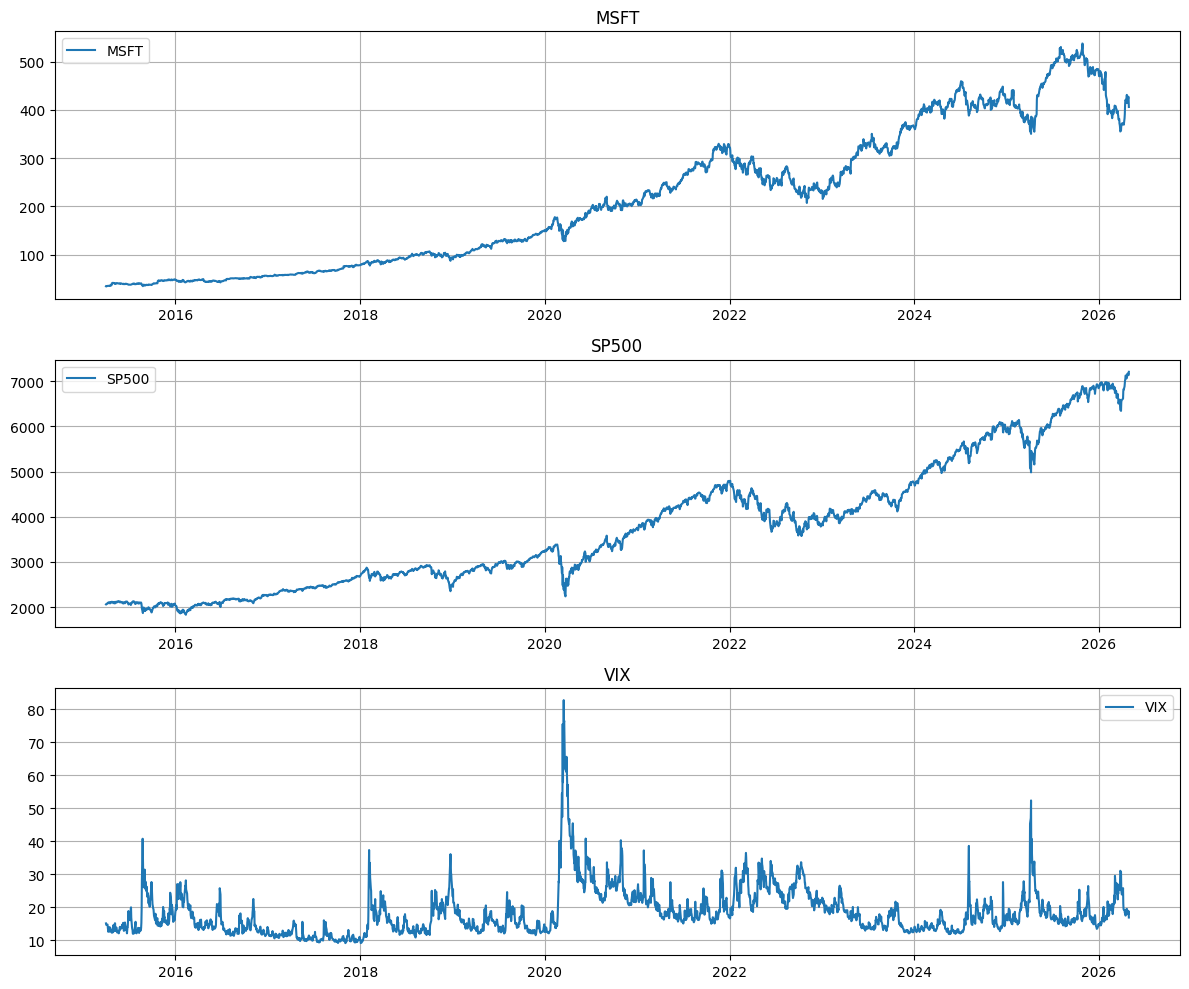

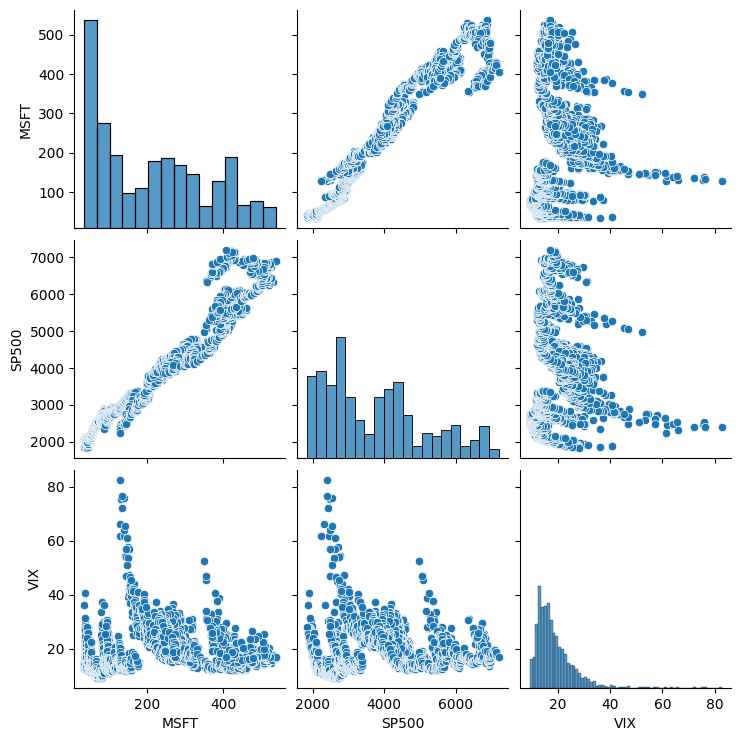

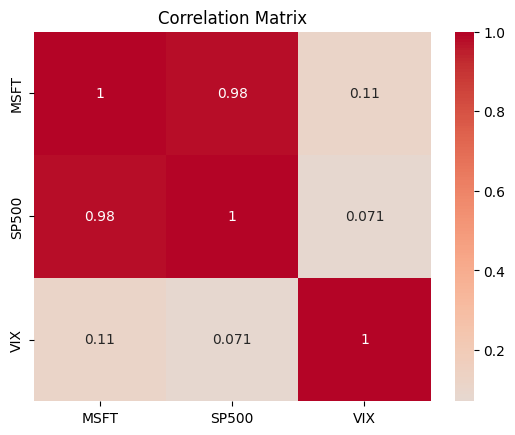

In [13]:
import seaborn as sns

# Line plots
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for i, col in enumerate(mv_df.columns):
    axes[i].plot(mv_df.index, mv_df[col], label=col)
    axes[i].set_title(col)
    axes[i].legend()
    axes[i].grid(True)
plt.tight_layout()
plt.show()

# Scatter matrix
sns.pairplot(mv_df)
plt.show()

# Correlation matrix
corr = mv_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### Stationarity Tests

In [14]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(series, title=""):
    print(f"\n=== {title} ===")
    adf = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {adf[0]:.6f}, p-value: {adf[1]:.6f}')
    kpss_stat, kpss_p, _, _ = kpss(series, regression='c')
    print(f'KPSS Statistic: {kpss_stat:.6f}, p-value: {kpss_p:.6f}')

# Test levels and first differences
for col in mv_df.columns:
    stationarity_tests(mv_df[col], f"Original {col}")
    stationarity_tests(mv_df[col].diff().dropna(), f"First Difference of {col}")


=== Original MSFT ===
ADF Statistic: -0.609983, p-value: 0.868710
KPSS Statistic: 8.368368, p-value: 0.010000

=== First Difference of MSFT ===


/tmp/ipykernel_576/2459236321.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, _, _ = kpss(series, regression='c')
/tmp/ipykernel_576/2459236321.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_p, _, _ = kpss(series, regression='c')


ADF Statistic: -17.524786, p-value: 0.000000
KPSS Statistic: 0.053690, p-value: 0.100000

=== Original SP500 ===
ADF Statistic: 1.134508, p-value: 0.995501
KPSS Statistic: 8.008017, p-value: 0.010000

=== First Difference of SP500 ===
ADF Statistic: -17.307838, p-value: 0.000000
KPSS Statistic: 0.243493, p-value: 0.100000

=== Original VIX ===


/tmp/ipykernel_576/2459236321.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, _, _ = kpss(series, regression='c')
/tmp/ipykernel_576/2459236321.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_p, _, _ = kpss(series, regression='c')


ADF Statistic: -5.744969, p-value: 0.000001
KPSS Statistic: 0.982760, p-value: 0.010000

=== First Difference of VIX ===
ADF Statistic: -12.369789, p-value: 0.000000
KPSS Statistic: 0.008687, p-value: 0.100000


/tmp/ipykernel_576/2459236321.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, _, _ = kpss(series, regression='c')
/tmp/ipykernel_576/2459236321.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_p, _, _ = kpss(series, regression='c')


### Cointegration Test (Johansen)

In [15]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen
lags = 5

def johansen_test(df, lags):
    """Perform Johansen cointegration test"""
    res = coint_johansen(df, det_order=0, k_ar_diff=lags)
    # Trace statistic
    trace_stat = res.lr1
    trace_crit = res.cvt[:, 1]  # 95% critical value
    # Max-eigen statistic
    max_eigen_stat = res.lr2
    max_eigen_crit = res.cvm[:, 1]

    print("\n=== Johansen Trace Test ===")
    for i in range(len(trace_stat)):
        print(f"H0: r<={i} | Trace Stat: {trace_stat[i]:.3f} | 95% crit: {trace_crit[i]:.3f}")

    print("\n=== Johansen Max-Eigen Test ===")
    for i in range(len(max_eigen_stat)):
        print(f"H0: r={i} | Max-Eigen Stat: {max_eigen_stat[i]:.3f} | 95% crit: {max_eigen_crit[i]:.3f}")

johansen_test(mv_df, lags=lags)


=== Johansen Trace Test ===
H0: r<=0 | Trace Stat: 78.391 | 95% crit: 29.796
H0: r<=1 | Trace Stat: 10.137 | 95% crit: 15.494
H0: r<=2 | Trace Stat: 2.219 | 95% crit: 3.841

=== Johansen Max-Eigen Test ===
H0: r=0 | Max-Eigen Stat: 68.254 | 95% crit: 21.131
H0: r=1 | Max-Eigen Stat: 7.917 | 95% crit: 14.264
H0: r=2 | Max-Eigen Stat: 2.219 | 95% crit: 3.841


### Model Order Selection (VAR/VECM)

In [16]:
from statsmodels.tsa.api import VAR

# Determine optimal lag order for a VAR model (in levels, but for VECM we use the same lags of differenced terms)
model_var = VAR(mv_df.diff().dropna())
lag_order = model_var.select_order(maxlags=10)
print(lag_order.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        10.10       10.11   2.441e+04       10.11
1        10.08      10.10*   2.379e+04       10.09
2        10.07       10.11   2.360e+04       10.09
3        10.07       10.13   2.353e+04       10.09
4        10.05       10.13   2.317e+04      10.08*
5        10.05       10.15   2.314e+04       10.09
6        10.05       10.17   2.314e+04       10.09
7        10.04       10.19   2.303e+04       10.10
8        10.04       10.20   2.300e+04       10.10
9        10.04       10.22   2.288e+04       10.10
10      10.04*       10.23  2.284e+04*       10.11
--------------------------------------------------


### Estimate the VECM (Vector Error Correction Model)

In [20]:
# --- Test which lag eliminates residual autocorrelation ---
from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.stats.diagnostic import acorr_ljungbox

best_lag = None
for k_ar_diff in [5,6,7,8]:
    vecm_test = VECM(mv_df, k_ar_diff=k_ar_diff, coint_rank=1, deterministic='ci')
    vecm_test_res = vecm_test.fit()
    residuals = pd.DataFrame(vecm_test_res.resid, columns=mv_df.columns)
    all_ok = True
    print(f"\n--- k_ar_diff = {k_ar_diff} ---")
    for col in residuals.columns:
        lb = acorr_ljungbox(residuals[col].dropna(), lags=[10], return_df=True)
        pval = lb['lb_pvalue'].values[0]
        status = "OK" if pval > 0.05 else "FAIL"
        print(f"  {col} p-value (lag 10) = {pval:.4f}  {status}")
        if pval <= 0.05:
            all_ok = False
    if all_ok:
        best_lag = k_ar_diff
        break

print(f"\n** Suggested k_ar_diff for white-noise residuals: {best_lag} **")


--- k_ar_diff = 5 ---
  MSFT p-value (lag 10) = 0.2770  OK
  SP500 p-value (lag 10) = 0.0072  FAIL
  VIX p-value (lag 10) = 0.0178  FAIL

--- k_ar_diff = 6 ---
  MSFT p-value (lag 10) = 0.6119  OK
  SP500 p-value (lag 10) = 0.0184  FAIL
  VIX p-value (lag 10) = 0.0274  FAIL

--- k_ar_diff = 7 ---
  MSFT p-value (lag 10) = 0.6409  OK
  SP500 p-value (lag 10) = 0.0871  OK
  VIX p-value (lag 10) = 0.0332  FAIL

--- k_ar_diff = 8 ---
  MSFT p-value (lag 10) = 0.8544  OK
  SP500 p-value (lag 10) = 0.4427  OK
  VIX p-value (lag 10) = 0.7341  OK

** Suggested k_ar_diff for white-noise residuals: 8 **


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, fr

In [21]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM

# --- Estimate VECM with chosen lag ---
k_ar_diff = 8   # lag selected by the residual autocorrelation check above
r = 1
vecm = VECM(mv_df, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci')
vecm_res = vecm.fit()
print(vecm_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation MSFT
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.MSFT       -0.0062      0.027     -0.231      0.817      -0.059       0.046
L1.SP500       0.0037      0.004      1.019      0.308      -0.003       0.011
L1.VIX         0.2292      0.063      3.616      0.000       0.105       0.353
L2.MSFT       -0.0785      0.027     -2.932      0.003      -0.131      -0.026
L2.SP500       0.0059      0.004      1.629      0.103      -0.001       0.013
L2.VIX        -0.0437      0.064     -0.686      0.493      -0.169       0.081
L3.MSFT        0.0615      0.027      2.289      0.022       0.009       0.114
L3.SP500      -0.0146      0.004     -4.017      0.000      -0.022      -0.007
L3.VIX        -0.1286      0.064     -2.018      0.044      -0.253      -0.004
L4.MSFT       -0.0091      0.027     -0.337    

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


### Diagnostic Checks

In [22]:
# Residual autocorrelation test (Portmanteau)
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd # Import pandas

residuals = pd.DataFrame(vecm_res.resid, columns=mv_df.columns) # Convert to DataFrame with original column names
for col in residuals.columns:
    lb = acorr_ljungbox(residuals[col].dropna(), lags=[10], return_df=True)
    print(f"\nLjung-Box for {col} residuals:")
    print(lb)


Ljung-Box for MSFT residuals:
     lb_stat  lb_pvalue
10  5.512913   0.854393

Ljung-Box for SP500 residuals:
    lb_stat  lb_pvalue
10  9.97487   0.442701

Ljung-Box for VIX residuals:
     lb_stat  lb_pvalue
10  6.908294   0.734073


### Impulse Response Functions

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


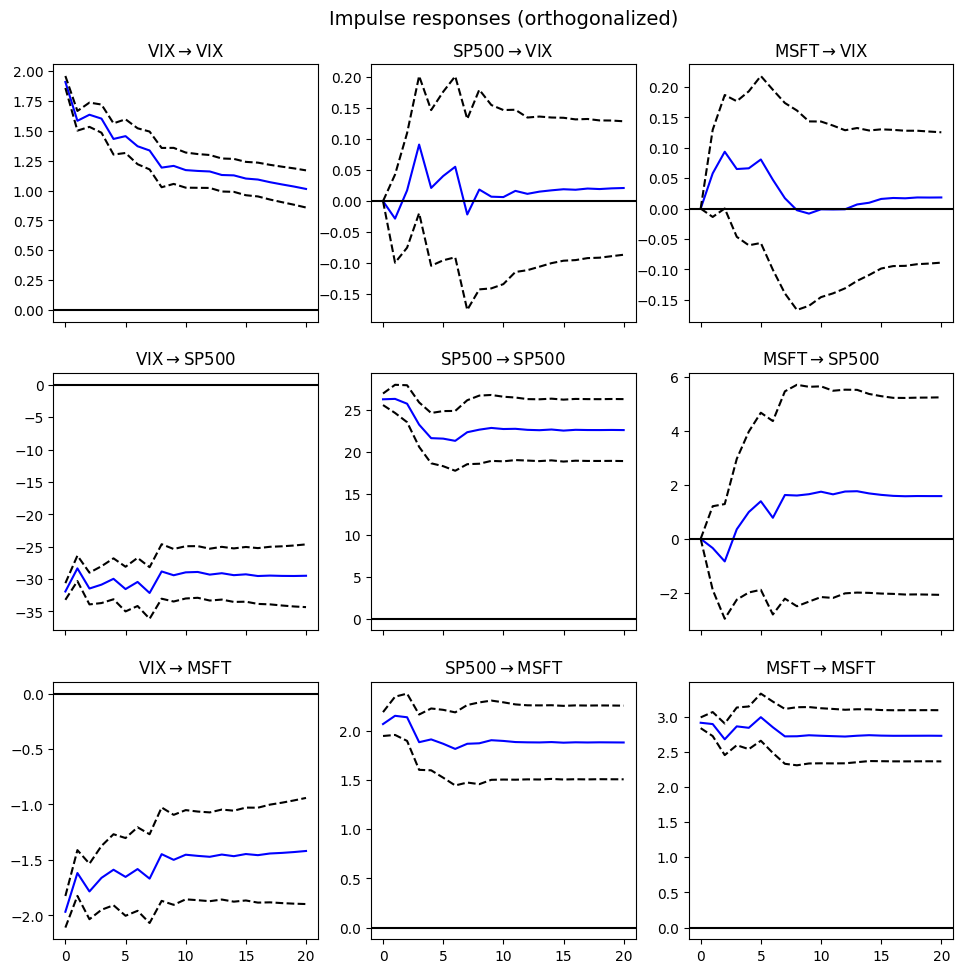

In [23]:
# Reorder columns for a meaningful causal ordering: VIX -> SP500 -> MSFT
mv_df_reorder = mv_df[['VIX','SP500','MSFT']].copy()
vecm_reorder = VECM(mv_df_reorder, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci')
vecm_reorder_res = vecm_reorder.fit()
irf_reorder = vecm_reorder_res.irf(periods=20)
irf_reorder.plot(orth=True)
plt.show()

### Forecasting

            MSFT_forecast    lower_CI    upper_CI
2026-05-01     408.057895  400.067760  416.048030
2026-05-04     409.342723  398.215627  420.469818
2026-05-05     408.014687  394.558108  421.471266
2026-05-06     407.374880  391.988828  422.760932
2026-05-07     406.085428  389.014206  423.156650


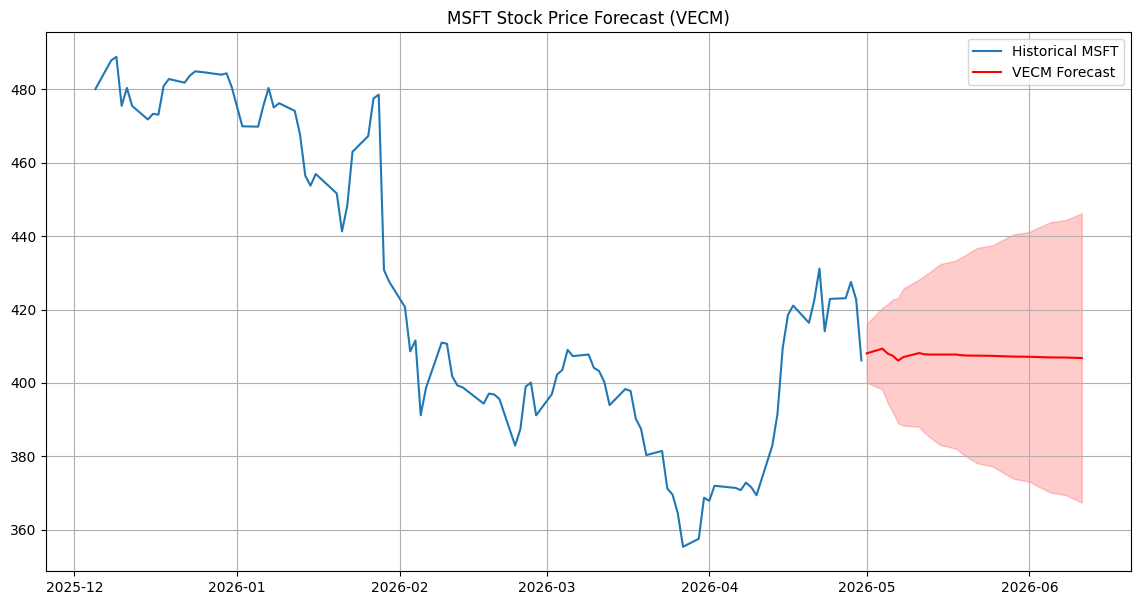

In [24]:
forecast_steps = 30
forecast, lower, upper = vecm_res.predict(forecast_steps, 0.05)

# Convert to DataFrame for the first variable (e.g., MSFT)
forecast_df = pd.DataFrame({
    'MSFT_forecast': forecast[:, 0],
    'lower_CI': lower[:, 0],
    'upper_CI': upper[:, 0]
}, index=pd.date_range(start=mv_df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='B'))

print(forecast_df.head())

# Plot MSFT forecast
plt.figure(figsize=(14,7))
plt.plot(mv_df.index[-100:], mv_df['MSFT'].iloc[-100:], label='Historical MSFT')
plt.plot(forecast_df.index, forecast_df['MSFT_forecast'], label='VECM Forecast', color='red')
plt.fill_between(forecast_df.index, forecast_df['lower_CI'], forecast_df['upper_CI'], alpha=0.2, color='red')
plt.title('MSFT Stock Price Forecast (VECM)')
plt.legend()
plt.grid(True)
plt.show()

#### Out‑of‑sample validation

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


MSFT – RMSE: 24.49, MAE: 22.60
SP500 – RMSE: 341.47, MAE: 278.03
VIX – RMSE: 3.96, MAE: 3.46


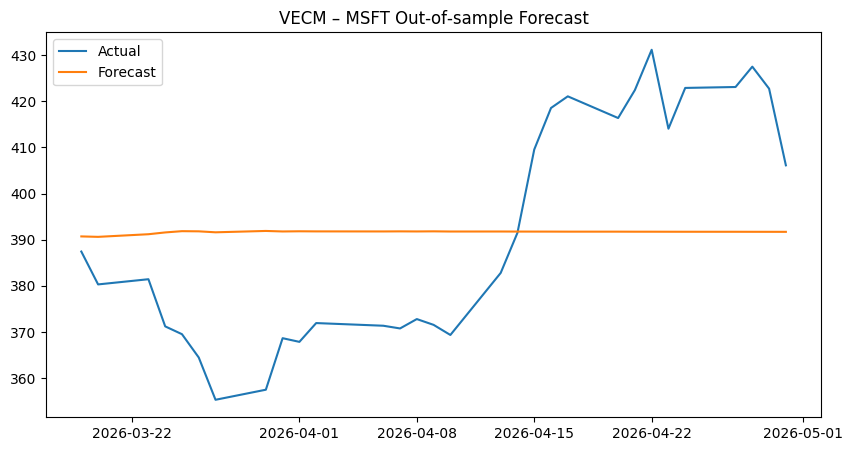

In [25]:
# --- Out-of-sample validation for VECM ---
test_len = 30
train_df = mv_df.iloc[:-test_len]
test_df  = mv_df.iloc[-test_len:]

# Fit VECM on training data (use the same k_ar_diff and r as above)
vecm_train = VECM(train_df, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci')
vecm_res_train = vecm_train.fit()

# Forecast test_len steps ahead
forecast_array = vecm_res_train.predict(steps=test_len)

# Convert the forecast NumPy array to a DataFrame with correct column names and index
forecast = pd.DataFrame(forecast_array, columns=mv_df.columns, index=test_df.index)

from sklearn.metrics import mean_squared_error
import numpy as np

for col in mv_df.columns:
    rmse = np.sqrt(mean_squared_error(test_df[col], forecast[col]))
    mae  = mean_absolute_error(test_df[col], forecast[col])
    print(f"{col} – RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# Optional: plot actual vs forecast for one variable
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(test_df.index, test_df['MSFT'], label='Actual')
plt.plot(forecast.index, forecast['MSFT'], label='Forecast')
plt.legend(); plt.title('VECM – MSFT Out‑of‑sample Forecast'); plt.show()

## PART 3: Conditional Heteroscedasticity (ARCH/GARCH)

In [26]:
import sys
!{sys.executable} -m pip install arch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 11.4 MB/s eta 0:00:00


### Test ARIMA Residuals for ARCH Effects

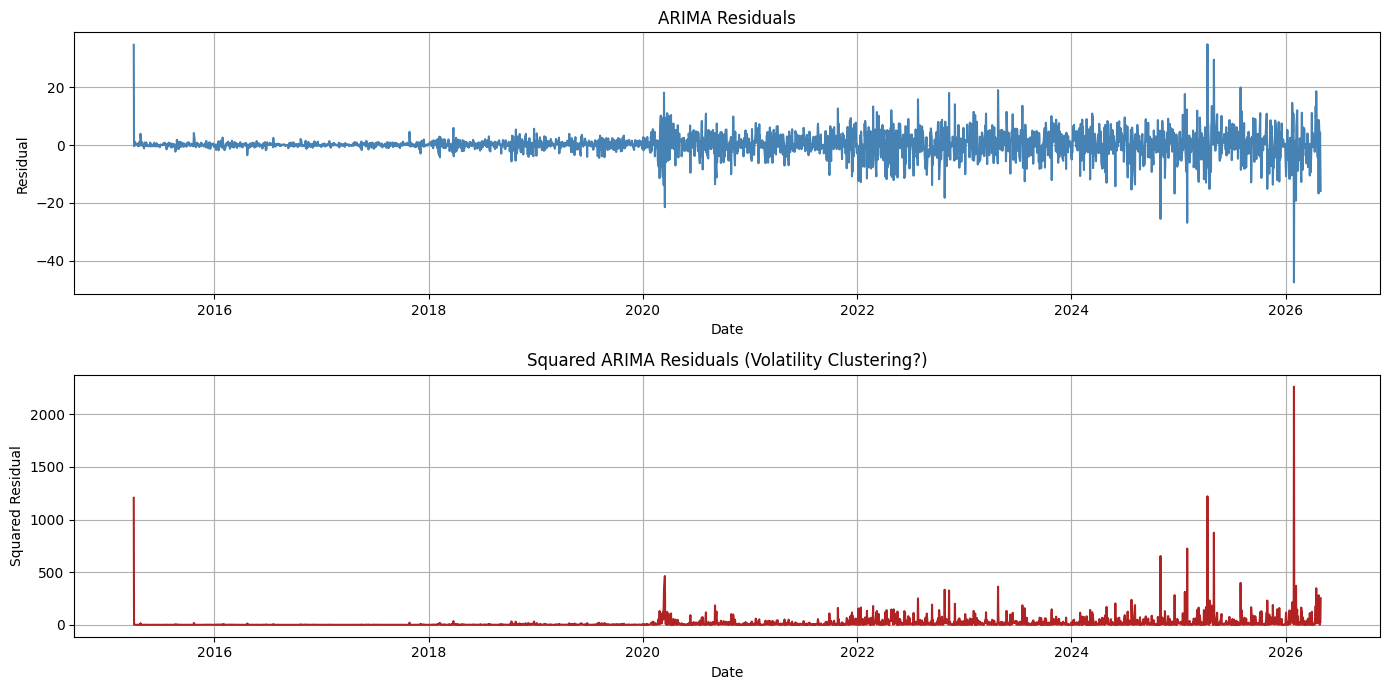

ARCH-LM Test on ARIMA Residuals
Lags= 5 | LM Stat: 123.1704 | p-value: 0.000000 | ARCH effects present ✗
Lags=10 | LM Stat: 156.1968 | p-value: 0.000000 | ARCH effects present ✗
Lags=15 | LM Stat: 183.6884 | p-value: 0.000000 | ARCH effects present ✗


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch.unitroot import PhillipsPerron
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model

# ── Retrieve residuals from the Part 1 ARIMA model ──
arima_resid = arima_model.resid.dropna()

# Plot residuals and squared residuals
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(arima_resid, color='steelblue')
axes[0].set_title('ARIMA Residuals')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual')
axes[0].grid(True)

axes[1].plot(arima_resid**2, color='firebrick')
axes[1].set_title('Squared ARIMA Residuals (Volatility Clustering?)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Squared Residual')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ── ARCH-LM Test on ARIMA residuals ──
print("=" * 55)
print("ARCH-LM Test on ARIMA Residuals")
print("=" * 55)
for lag in [5, 10, 15]:
    lm_stat, lm_pval, f_stat, f_pval = het_arch(arima_resid, nlags=lag)
    result = "ARCH effects present ✗" if lm_pval < 0.05 else "No ARCH effects ✓"
    print(f"Lags={lag:2d} | LM Stat: {lm_stat:.4f} | p-value: {lm_pval:.6f} | {result}")

### Test VECM Residuals for ARCH Effects

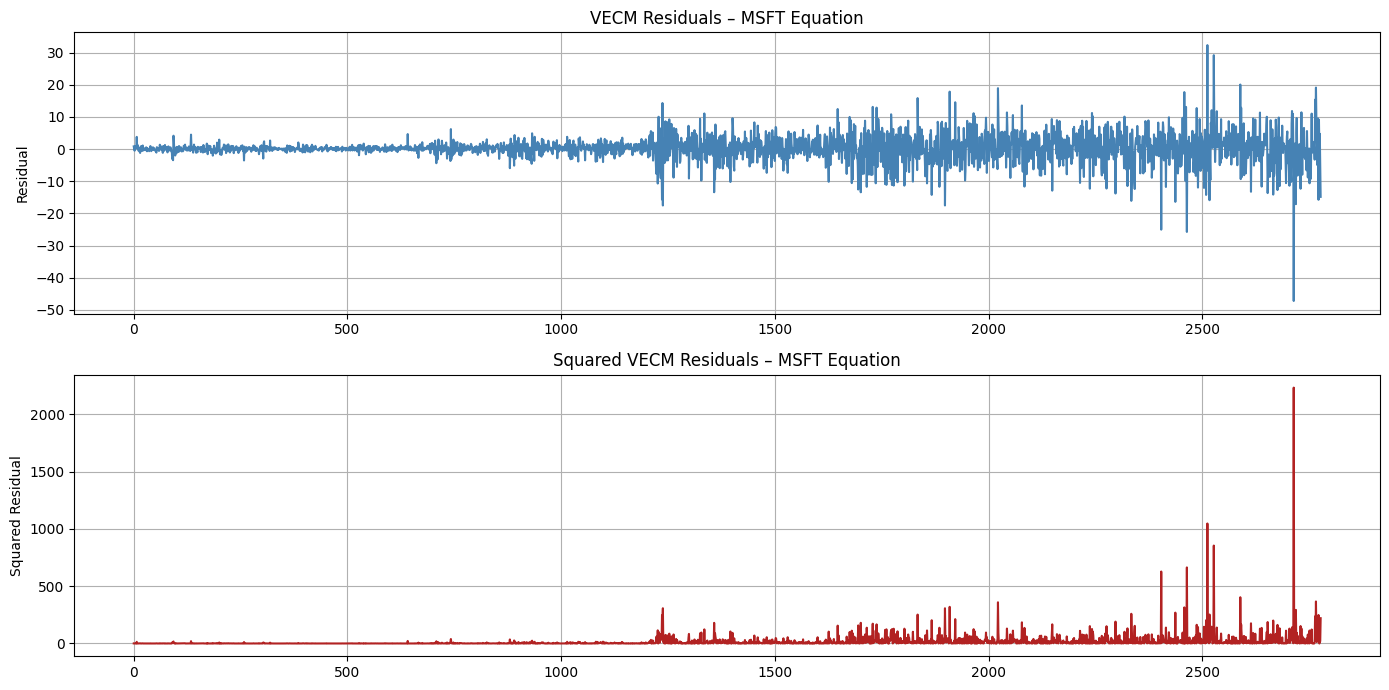

ARCH-LM Test on VECM Residuals (MSFT equation)
Lags= 5 | LM Stat: 111.1921 | p-value: 0.000000 | ARCH effects present ✗
Lags=10 | LM Stat: 141.4155 | p-value: 0.000000 | ARCH effects present ✗
Lags=15 | LM Stat: 167.9833 | p-value: 0.000000 | ARCH effects present ✗


In [28]:
# ── ARCH-LM Test on VECM residuals (MSFT equation only) ──
vecm_resid_msft = pd.Series(vecm_res.resid[:, mv_df.columns.get_loc('MSFT')],
                             name='VECM_MSFT_resid')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(vecm_resid_msft.values, color='steelblue')
axes[0].set_title('VECM Residuals – MSFT Equation')
axes[0].set_ylabel('Residual')
axes[0].grid(True)

axes[1].plot(vecm_resid_msft.values**2, color='firebrick')
axes[1].set_title('Squared VECM Residuals – MSFT Equation')
axes[1].set_ylabel('Squared Residual')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("=" * 55)
print("ARCH-LM Test on VECM Residuals (MSFT equation)")
print("=" * 55)
for lag in [5, 10, 15]:
    lm_stat, lm_pval, f_stat, f_pval = het_arch(vecm_resid_msft.dropna(), nlags=lag)
    result = "ARCH effects present ✗" if lm_pval < 0.05 else "No ARCH effects ✓"
    print(f"Lags={lag:2d} | LM Stat: {lm_stat:.4f} | p-value: {lm_pval:.6f} | {result}")

### Fit GARCH(1,1) on ARIMA Residuals

In [29]:
# ── GARCH(1,1) on ARIMA residuals ──
print("=" * 55)
print("GARCH(1,1) – ARIMA Residuals")
print("=" * 55)

garch_arima = arch_model(arima_resid, vol='Garch', p=1, q=1, dist='normal')
garch_arima_res = garch_arima.fit(disp='off')
print(garch_arima_res.summary())

GARCH(1,1) – ARIMA Residuals
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6596.60
Distribution:                  Normal   AIC:                           13201.2
Method:            Maximum Likelihood   BIC:                           13224.9
                                        No. Observations:                 2787
Date:                Thu, Oct 08 2026   Df Residuals:                     2786
Time:                        08:48:23   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0887  2.326e-02   

### Model Selection: Compare GARCH Variants

In [30]:
# ── Compare GARCH variants to select best model ──
results_table = []

specs = [
    ('GARCH(1,1)',   dict(vol='Garch',  p=1, q=1, dist='normal')),
    ('GARCH(1,1)-t', dict(vol='Garch',  p=1, q=1, dist='t')),
    ('EGARCH(1,1)',  dict(vol='EGARCH', p=1, q=1, dist='normal')),
    ('GJR-GARCH',   dict(vol='GARCH',  p=1, o=1, q=1, dist='normal')),
]

print(f"{'Model':<20} {'AIC':>10} {'BIC':>10} {'Log-Lik':>12}")
print("-" * 55)
for name, kwargs in specs:
    try:
        m = arch_model(arima_resid, **kwargs).fit(disp='off')
        print(f"{name:<20} {m.aic:>10.2f} {m.bic:>10.2f} {m.loglikelihood:>12.2f}")
        results_table.append((name, m.aic, m.bic))
    except Exception as e:
        print(f"{name:<20} Failed: {e}")

best_model_name = min(results_table, key=lambda x: x[1])[0]
print(f"\n✔ Best model by AIC: {best_model_name}")

Model                       AIC        BIC      Log-Lik
-------------------------------------------------------
GARCH(1,1)             13201.20   13224.93     -6596.60
GARCH(1,1)-t           12810.89   12840.55     -6400.44
EGARCH(1,1)            13141.47   13165.20     -6566.73
GJR-GARCH              13203.17   13232.83     -6596.58

✔ Best model by AIC: GARCH(1,1)-t


### Fit Best GARCH Model & Diagnostics

In [31]:
# ── Fit best model (GARCH(1,1)-t had the lowest AIC above) ──
best_garch = arch_model(arima_resid, vol='Garch', p=1, q=1, dist='t')
best_garch_res = best_garch.fit(disp='off')
print(best_garch_res.summary())

# ── Parameter interpretation ──
params = best_garch_res.params
alpha = params['alpha[1]']
beta  = params['beta[1]']
print(f"\nomega  = {params['omega']:.6f}")
print(f"alpha1 = {alpha:.4f}  (ARCH effect – reaction to shocks)")
print(f"beta1  = {beta:.4f}   (GARCH effect – volatility persistence)")
print(f"alpha1 + beta1 = {alpha+beta:.4f}  (persistence; <1 required for stationarity)")

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6400.44
Distribution:      Standardized Student's t   AIC:                           12810.9
Method:                  Maximum Likelihood   BIC:                           12840.6
                                              No. Observations:                 2787
Date:                      Thu, Oct 08 2026   Df Residuals:                     2786
Time:                              08:48:24   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

### GARCH Diagnostics (Standardised Residuals)

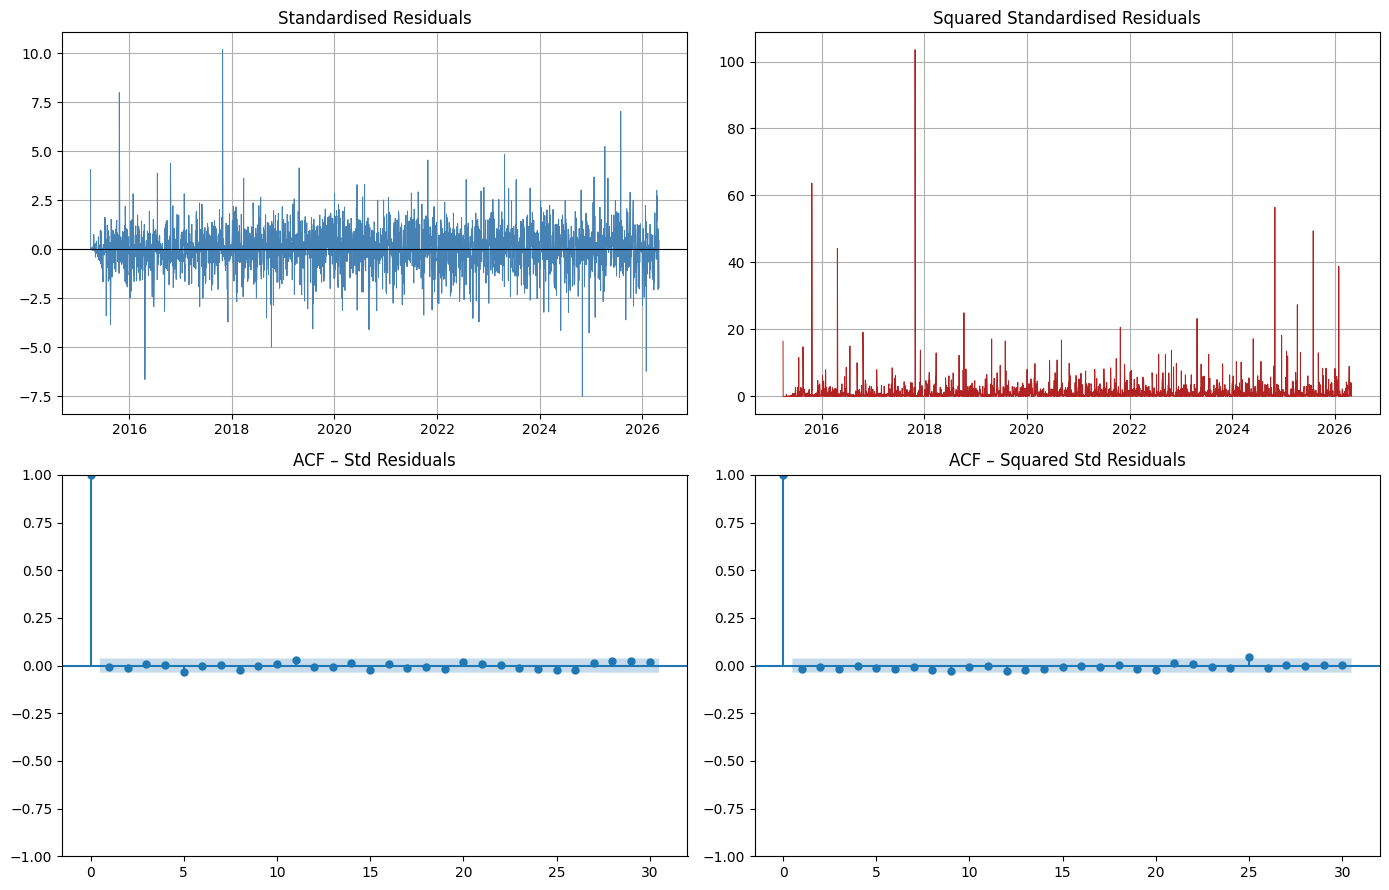

Ljung-Box on Standardised Residuals (should be non-significant):
      lb_stat  lb_pvalue
10   5.614836   0.846519
20  12.654042   0.891729

Ljung-Box on SQUARED Standardised Residuals (should be non-significant):
      lb_stat  lb_pvalue
10   7.902088   0.638400
20  15.927751   0.721096

ARCH-LM Test on Standardised Residuals (confirm ARCH effects removed):
Lags= 5 | p-value: 0.752138 | ARCH effects removed ✓
Lags=10 | p-value: 0.581250 | ARCH effects removed ✓


In [32]:
# ── Standardised residual diagnostics ──
std_resid = best_garch_res.std_resid

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Standardised residuals over time
axes[0,0].plot(std_resid, color='steelblue', linewidth=0.7)
axes[0,0].axhline(0, color='black', linewidth=0.8)
axes[0,0].set_title('Standardised Residuals')
axes[0,0].grid(True)

# 2. Squared standardised residuals
axes[0,1].plot(std_resid**2, color='firebrick', linewidth=0.7)
axes[0,1].set_title('Squared Standardised Residuals')
axes[0,1].grid(True)

# 3. ACF of standardised residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_resid, lags=30, ax=axes[1,0], title='ACF – Std Residuals')

# 4. ACF of squared standardised residuals
plot_acf(std_resid**2, lags=30, ax=axes[1,1], title='ACF – Squared Std Residuals')

plt.tight_layout()
plt.show()

# ── Ljung-Box on standardised and squared standardised residuals ──
from statsmodels.stats.diagnostic import acorr_ljungbox
print("Ljung-Box on Standardised Residuals (should be non-significant):")
print(acorr_ljungbox(std_resid, lags=[10, 20], return_df=True))

print("\nLjung-Box on SQUARED Standardised Residuals (should be non-significant):")
print(acorr_ljungbox(std_resid**2, lags=[10, 20], return_df=True))

# ── ARCH-LM test on standardised residuals (confirm ARCH removed) ──
print("\nARCH-LM Test on Standardised Residuals (confirm ARCH effects removed):")
for lag in [5, 10]:
    lm_stat, lm_pval, _, _ = het_arch(std_resid, nlags=lag)
    result = "ARCH effects remain ✗" if lm_pval < 0.05 else "ARCH effects removed ✓"
    print(f"Lags={lag:2d} | p-value: {lm_pval:.6f} | {result}")

### Conditional Volatility Plot

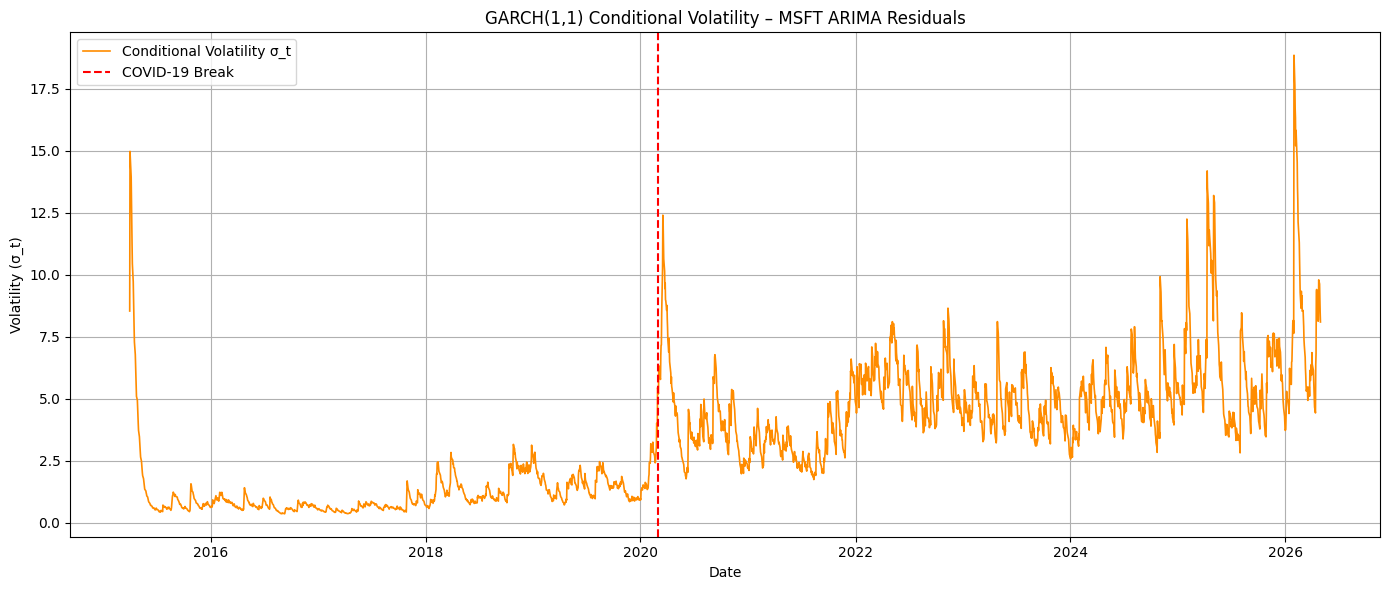

In [33]:
# ── Plot conditional volatility (the estimated σ_t) ──
cond_vol = best_garch_res.conditional_volatility

plt.figure(figsize=(14, 6))
plt.plot(arima_resid.index, cond_vol, color='darkorange', linewidth=1.2, label='Conditional Volatility σ_t')
plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=1.5, label='COVID-19 Break')
plt.title('GARCH(1,1) Conditional Volatility – MSFT ARIMA Residuals')
plt.xlabel('Date')
plt.ylabel('Volatility (σ_t)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### GARCH on VECM Residuals (MSFT Equation)

GARCH(1,1) – VECM Residuals (MSFT Equation)
                        Constant Mean - GARCH Model Results                         
Dep. Variable:              VECM_MSFT_resid   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6425.33
Distribution:      Standardized Student's t   AIC:                           12860.7
Method:                  Maximum Likelihood   BIC:                           12890.3
                                              No. Observations:                 2778
Date:                      Thu, Oct 08 2026   Df Residuals:                     2777
Time:                              08:48:25   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-----------------------------------------

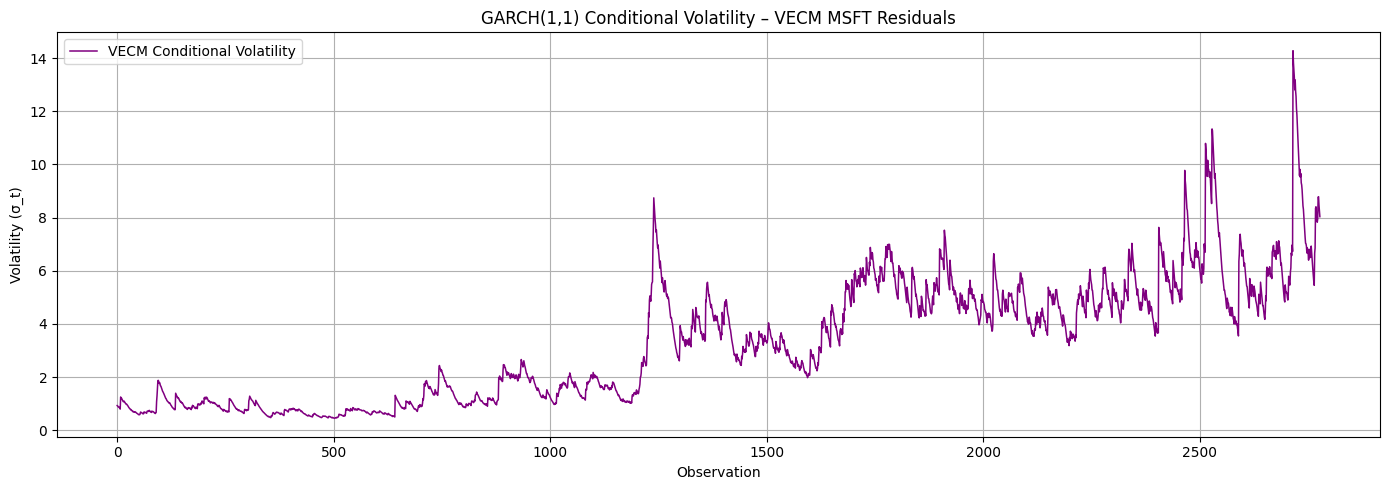

In [34]:
# ── GARCH(1,1) on VECM residuals – MSFT equation ──
print("=" * 55)
print("GARCH(1,1) – VECM Residuals (MSFT Equation)")
print("=" * 55)

garch_vecm = arch_model(vecm_resid_msft, vol='Garch', p=1, q=1, dist='t')
garch_vecm_res = garch_vecm.fit(disp='off')
print(garch_vecm_res.summary())

# Plot conditional volatility
cond_vol_vecm = garch_vecm_res.conditional_volatility
plt.figure(figsize=(14, 5))
plt.plot(cond_vol_vecm.values, color='purple', linewidth=1.1, label='VECM Conditional Volatility')
plt.title('GARCH(1,1) Conditional Volatility – VECM MSFT Residuals')
plt.xlabel('Observation')
plt.ylabel('Volatility (σ_t)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Volatility Forecast (30 Days)

Volatility Forecast – Next 30 Business Days:
            Forecast_Volatility  Forecast_Variance
2026-05-01             9.547775          91.160004
2026-05-04             9.548415          91.172237
2026-05-05             9.549056          91.184469
2026-05-06             9.549696          91.196701
2026-05-07             9.550337          91.208933
2026-05-08             9.550977          91.221165
2026-05-11             9.551618          91.233397
2026-05-12             9.552258          91.245629
2026-05-13             9.552898          91.257861
2026-05-14             9.553538          91.270094
2026-05-15             9.554178          91.282326
2026-05-18             9.554819          91.294558
2026-05-19             9.555459          91.306790
2026-05-20             9.556099          91.319022
2026-05-21             9.556739          91.331254
2026-05-22             9.557379          91.343487
2026-05-25             9.558019          91.355719
2026-05-26             9.558658      

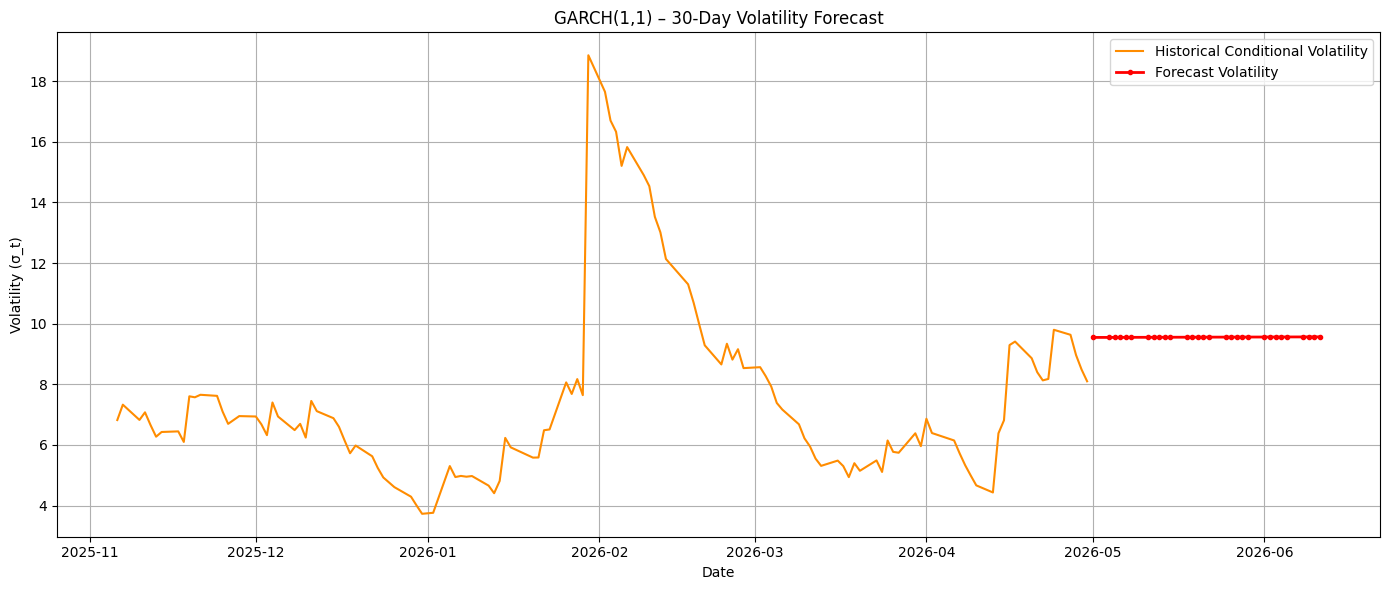

In [35]:
# ── Volatility forecast: next 30 business days ──
vol_forecast = best_garch_res.forecast(horizon=30, reindex=False)

forecast_variance = vol_forecast.variance.iloc[-1]
forecast_vol      = np.sqrt(forecast_variance)

future_dates = pd.date_range(
    start=arima_resid.index[-1] + pd.Timedelta(days=1),
    periods=30, freq='B'
)

vol_forecast_df = pd.DataFrame({
    'Forecast_Volatility': forecast_vol.values,
    'Forecast_Variance':   forecast_variance.values
}, index=future_dates)

print("Volatility Forecast – Next 30 Business Days:")
print(vol_forecast_df.round(6))

# Plot
plt.figure(figsize=(14, 6))
plt.plot(arima_resid.index[-120:], cond_vol[-120:],
         color='darkorange', label='Historical Conditional Volatility')
plt.plot(vol_forecast_df.index, vol_forecast_df['Forecast_Volatility'],
         color='red', linewidth=2, marker='o', markersize=3, label='Forecast Volatility')
plt.title('GARCH(1,1) – 30-Day Volatility Forecast')
plt.xlabel('Date')
plt.ylabel('Volatility (σ_t)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Summary Table

In [36]:
# ── Final summary table ──
print("=" * 60)
print("PART 3 SUMMARY – ARCH/GARCH RESULTS")
print("=" * 60)

arima_lm = het_arch(arima_resid, nlags=10)
vecm_lm  = het_arch(vecm_resid_msft.dropna(), nlags=10)

p_arima = params['alpha[1]']
b_arima = params['beta[1]']

p_vecm  = garch_vecm_res.params['alpha[1]']
b_vecm  = garch_vecm_res.params['beta[1]']

print(f"\n{'Model':<25} {'ARCH-LM p-val':>15} {'alpha1':>8} {'beta1':>8} {'Persist.':>10}")
print("-" * 70)
print(f"{'ARIMA residuals':<25} {arima_lm[1]:>15.6f} {p_arima:>8.4f} {b_arima:>8.4f} {p_arima+b_arima:>10.4f}")
print(f"{'VECM residuals (MSFT)':<25} {vecm_lm[1]:>15.6f} {p_vecm:>8.4f} {b_vecm:>8.4f} {p_vecm+b_vecm:>10.4f}")
print("\n✔ Both models exhibit significant ARCH effects → GARCH(1,1) applied to both.")

PART 3 SUMMARY – ARCH/GARCH RESULTS

Model                       ARCH-LM p-val   alpha1    beta1   Persist.
----------------------------------------------------------------------
ARIMA residuals                  0.000000   0.1343   0.8657     1.0000
VECM residuals (MSFT)            0.000000   0.0721   0.9279     1.0000

✔ Both models exhibit significant ARCH effects → GARCH(1,1) applied to both.
